# CLT similarity: **apricot** base vs its self-data fine-tune

This notebook quantifies **how similar** the apricot CLT is to `apricot-finetune-basic`
— the version produced by continue-training ("fine-tuning") apricot on its **own
original** `grid-L4-H6` model + **own original** bioS data. It answers the practical
question: *can I keep using apricot's existing feature labels/dashboards for the
fine-tuned CLT?*

> **This is not fact editing.** The fine-tune only *reads* the original model; it changes
> no model weights. A CLT is a sparse read-out dictionary — it can't edit anything.

**Why a direct, index-aligned comparison is valid here.** The fine-tune was made with
`--resume-from` the base CLT, so feature `i` in both CLTs is the *same feature* (it only
drifted during training). Comparing `W_dec[i]` vs `W_dec[i]` and "feature `i` firing" vs
"feature `i` firing" is therefore meaningful — no greedy feature matching needed. (That
matching *would* be required for two independently trained from-scratch CLTs.)

All numbers below come from `finetuning/compare_clts.py` (imported as `cc`); the notebook
just calls those functions and plots the results, so the CLI and the notebook are
guaranteed consistent.

In [1]:
%matplotlib inline
import os, sys, json
from pathlib import Path
import numpy as np, torch, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def find_repo_root(start):
    for cand in [Path(start).resolve(), *Path(start).resolve().parents]:
        if (cand / "clts" / "clt.py").exists() and (cand / "finetuning").exists():
            return cand
    raise RuntimeError("repo root not found from " + str(start))

REPO = find_repo_root(os.getcwd())
os.chdir(REPO)
sys.path.insert(0, str(REPO)); sys.path.insert(0, str(REPO / "finetuning"))
import compare_clts as cc

# --- CONFIG -----------------------------------------------------------------
# Point ROOT at your LM4_Results (the PSC path, or a local mirror of it). The
# env var wins so you can run the same notebook on PSC or locally unchanged.
ROOT = os.environ.get("CLT_STORAGE_ROOT", "/jet/home/friedmae/data_storage/LM4_Results")
os.environ["CLT_STORAGE_ROOT"] = ROOT
DEVICE = os.environ.get("COMPARE_DEVICE", "cpu")   # cpu => deterministic fp32
N_ROWS, N_EVAL_ROWS, CHUNK_ROWS, SAMPLE_SEED = 256, 64, 16, 2
print("repo  :", REPO)
print("root  :", ROOT)
print("device:", DEVICE)

/Users/efmac/Code/Project Code/CRL-Interp/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


repo  : /Users/efmac/Code/Project Code/CRL-Interp/Interp_LM4
root  : /private/tmp/claude-501/-Users-efmac-Code-Project-Code-CRL-Interp/a717b9b5-b4d4-4e5e-a1c2-6d69bdf8ed65/scratchpad/LM4_Results
device: cpu


In [2]:
# Load model + tokenizer + a random bioS token sample + both CLTs (shared setup).
paths = cc._default_paths()
ctx = cc.load_context(
    paths["model_dir"], paths["data_dir"], paths["clt_a"], paths["clt_b"],
    device=DEVICE, n_rows=N_ROWS, n_eval_rows=N_EVAL_ROWS, sample_seed=SAMPLE_SEED)
LA, LB = ctx["label_a"], ctx["label_b"]

[device] cpu


Loading weights:   0%|          | 0/38 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 38/38 [00:00<00:00, 36059.63it/s]

Moving model to device:  cpu
[model] /private/tmp/claude-501/-Users-efmac-Code-Project-Code-CRL-Interp/a717b9b5-b4d4-4e5e-a1c2-6d69bdf8ed65/scratchpad/LM4_Results/runResults/bioS_N-Bd_final_grid/20260520-134455/grid/grid-L4-H6/final
        n_layers=4 d_model=384


[data] sample rows=256 eval rows=64 (seed=2, ctx=512)
[clts] a=apricot b=finetune  n_layers=4 d_transcoder=6144



## Methodology

**Metric families** (all index-aligned):

1. **Quality** — each CLT standalone, on a held-out batch:
   - `ce_recovered` = (CE with MLPs zeroed − CE with CLT) / (CE zeroed − CE original).
     `1.0` = the CLT fully stands in for the MLPs; `0` = no better than deleting them.
   - `L0` = mean number of features active per token (sparsity).
   - `nMSE` = reconstruction MSE / Var(target), per layer.
2. **Weight-space similarity** — weights only:
   - **encoder cosine** — per-feature cosine of encoder rows = the feature *detectors*.
   - **decoder cosine** — per-feature cosine of the *summed* decoder vectors = the feature
     *outputs*. **Read weighted by feature importance** (decoder norm): a sparse CLT has
     ~half its features near-dead with ≈zero-norm decoders whose direction is
     unconstrained and drifts freely, tanking the raw mean even when nothing meaningful
     moved.
3. **Behavioral similarity** — both CLTs run on the same random bioS sample:
   - per-token **firing Jaccard** — of the features firing at a token, what fraction is
     shared between the two CLTs.
   - per-feature **activation Pearson** — correlation of feature `i`'s activation trace
     across all sampled tokens (the sharpest "same feature → same behavior" test).
   - **appeared / disappeared / dead** feature counts.
4. **Per-prompt** — top-k firing features per layer, base vs fine-tune, on single prompts.

## 1 · Quality (does the fine-tune help, hurt, or neither?)

In [3]:
qa = cc.quality_metrics(ctx["model"], ctx["clt_a"], ctx["eval_tokens"], ctx["enc_t"], ctx["dec_t"])
qb = cc.quality_metrics(ctx["model"], ctx["clt_b"], ctx["eval_tokens"], ctx["enc_t"], ctx["dec_t"])

df_q = pd.DataFrame({
    "ce_recovered (higher=better)":  [qa["ce_recovered"], qb["ce_recovered"]],
    "L0  mean active/token":         [qa["l0_mean"],      qb["l0_mean"]],
    "nMSE (lower=better)":           [qa["nmse_mean"],    qb["nmse_mean"]],
}, index=[LA, LB]).T
display(df_q.round(4))

df_layer = pd.DataFrame({
    f"L0·{LA}":   qa["l0_per_layer"],   f"L0·{LB}":   qb["l0_per_layer"],
    f"nMSE·{LA}": qa["nmse_per_layer"], f"nMSE·{LB}": qb["nmse_per_layer"],
}); df_layer.index.name = "layer"
display(df_layer.round(4))

,apricot,finetune
ce_recovered (higher=better),0.9161,0.9159
L0 mean active/token,132.4924,134.1181
nMSE (lower=better),0.2588,0.2585


,L0·apricot,L0·finetune,nMSE·apricot,nMSE·finetune
layer,,,,
0,48.3955,52.3309,0.0425,0.0416
1,90.5957,92.2190,0.4418,0.4420
2,88.2162,89.2255,0.5499,0.5493
3,302.7623,302.6968,0.0010,0.0010


**Read:** `ce_recovered`, `L0`, and `nMSE` are essentially identical between the two CLTs.
The fine-tune is a **functional no-op on quality** — expected, because apricot was already
*converged* on this exact model + data, so continue-training at LR 2e-5 just nudges it
around the same optimum. Not better, not worse.

## 2 · Weight-space similarity (are the features the same objects?)

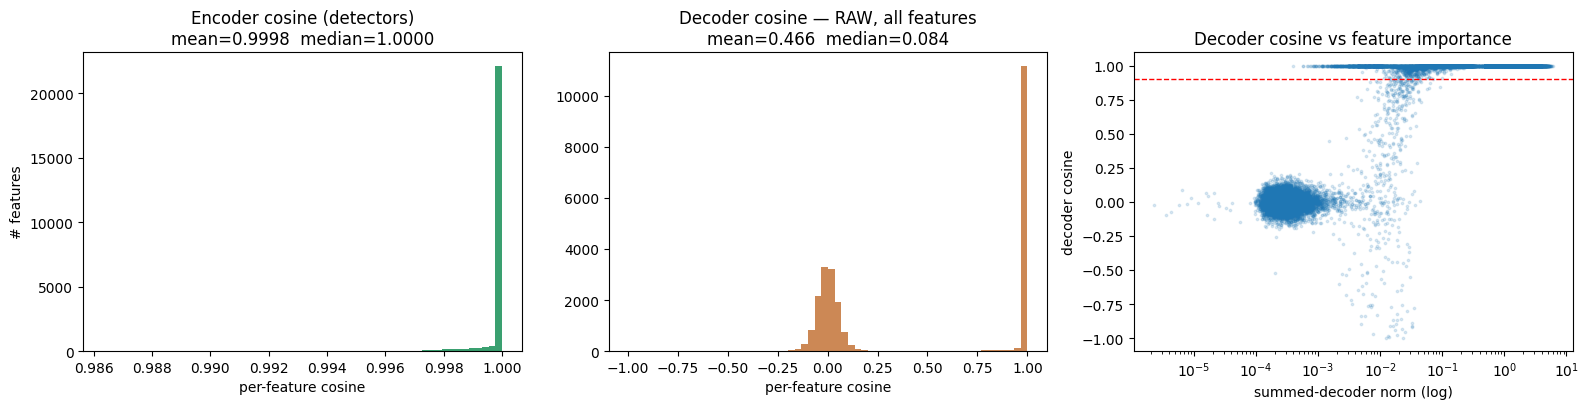

norm-weighted mean decoder cosine = 0.9988
'moved' (<0.9) feats: median decoder-norm = 0.0003   |   'stable' (>=0.9): median decoder-norm = 0.5342


,mean,median,frac_gt_0.99,min_norm_in_stratum
features kept (by decoder norm),,,,
top_10pct_by_norm,1.0000,1.0,1.0000,1.3084
top_25pct_by_norm,1.0000,1.0,1.0000,0.5261
top_50pct_by_norm,0.9311,1.0,0.8835,0.0008


In [4]:
raw = cc.per_feature_weight_cosines(ctx["clt_a"], ctx["clt_b"])
ws  = cc.weight_similarity(ctx["clt_a"], ctx["clt_b"])
enc  = raw["encoder_cos"].cpu().numpy()
dec  = raw["decoder_cos"].cpu().numpy()
norm = raw["decoder_norm_a"].cpu().numpy()

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ax[0].hist(enc, bins=60, color="#3aa070")
ax[0].set(title=f"Encoder cosine (detectors)\nmean={enc.mean():.4f}  median={np.median(enc):.4f}",
          xlabel="per-feature cosine", ylabel="# features")
ax[1].hist(dec, bins=60, color="#cc8855")
ax[1].set(title=f"Decoder cosine — RAW, all features\nmean={dec.mean():.3f}  median={np.median(dec):.3f}",
          xlabel="per-feature cosine")
ax[2].scatter(np.maximum(norm, 1e-6), dec, s=3, alpha=0.15)
ax[2].set_xscale("log")
ax[2].axhline(0.9, ls="--", c="r", lw=1)
ax[2].set(title="Decoder cosine vs feature importance", xlabel="summed-decoder norm (log)",
          ylabel="decoder cosine")
plt.tight_layout(); plt.show()

di = ws["decoder_by_importance"]
print(f"norm-weighted mean decoder cosine = {di['norm_weighted_mean_cosine']:.4f}")
print(f"'moved' (<0.9) feats: median decoder-norm = {di['moved_lt_0.9_median_norm']:.4f}"
      f"   |   'stable' (>=0.9): median decoder-norm = {di['stable_ge_0.9_median_norm']:.4f}")
strat = pd.DataFrame(di["strata"]).T[["mean", "median", "frac_gt_0.99", "min_norm_in_stratum"]]
strat.index.name = "features kept (by decoder norm)"
display(strat.round(4))

**Read:** the encoder (feature *detectors*) is essentially unchanged (cosine ≈ 1.0). The
decoder histogram *looks* alarming — bimodal with a big mass near 0 — but the scatter on
the right explains it: **every low-cosine feature sits at near-zero decoder norm**. Those
are dead/vestigial features whose output direction is unconstrained and drifts freely; it
has no effect on the model. Restrict to the features that actually carry the reconstruction
(top-N by decoder norm) and decoder cosine snaps to **1.0**; norm-weighted it's ≈ 0.999. The
features that matter are unchanged.

## 3 · Behavioral similarity (do the same features fire the same way?)

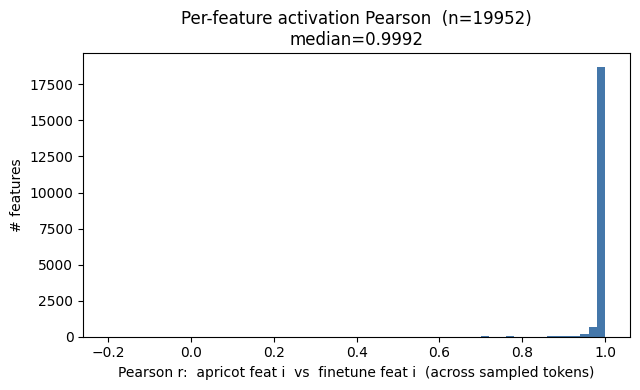

,value
per-token firing Jaccard (mean),0.9710
activation Pearson — mean,0.9918
activation Pearson — median,0.9992
frac features r > 0.9,0.9867
frac features r > 0.99,0.8875
frac features r < 0.5,0.0027
features fired in both,19952.0000
appeared (finetune only),490.0000
disappeared (apricot only),13.0000
dead features · apricot,4611.0000


In [5]:
bs = cc.behavioral_similarity(
    ctx["model"], ctx["clt_a"], ctx["clt_b"], ctx["sample_tokens"],
    ctx["enc_t"], ctx["dec_t"], chunk_rows=CHUNK_ROWS, return_arrays=True)
cors = bs["arrays"]["activation_pearson"].cpu().numpy()

plt.figure(figsize=(6.5, 4))
plt.hist(cors, bins=60, range=(-0.2, 1.0), color="#4477aa")
plt.title(f"Per-feature activation Pearson  (n={cors.size})\nmedian={np.median(cors):.4f}")
plt.xlabel(f"Pearson r:  {LA} feat i  vs  {LB} feat i  (across sampled tokens)")
plt.ylabel("# features"); plt.tight_layout(); plt.show()

ap = bs["activation_pearson"]
summ = pd.Series({
    "per-token firing Jaccard (mean)": bs["per_token_firing_jaccard_mean"],
    "activation Pearson — mean":       ap["mean"],
    "activation Pearson — median":     ap["median"],
    "frac features  r > 0.9":          ap["frac_gt_0.9"],
    "frac features  r > 0.99":         ap["frac_gt_0.99"],
    "frac features  r < 0.5":          ap["frac_lt_0.5"],
    "features fired in both":          bs["n_fired_both"],
    f"appeared ({LB} only)":           bs["n_appeared_in_b_only"],
    f"disappeared ({LA} only)":        bs["n_disappeared_from_a"],
    f"dead features · {LA}":           bs["n_dead_a"],
    f"dead features · {LB}":           bs["n_dead_b"],
}, name="value")
display(summ.to_frame().round(4))

**Read:** on real inputs the two CLTs behave almost identically — ~97% of the features
firing at any token are shared, and the median per-feature activation correlation is
≈ 0.999 (nearly 90% of features above 0.99). The only real change is that a few hundred
previously-**dead** features woke up faintly during the warm-up re-densification (net dead
count drops), which is cosmetic.

## 4 · Which features fire on individual prompts

In [6]:
ex = cc.per_prompt_examples(
    ctx["model"], ctx["clt_a"], ctx["clt_b"], ctx["sample_tokens"],
    ctx["tokenizer"], ctx["enc_t"], ctx["dec_t"], n_prompts=3, top_k=8)

overlap = pd.DataFrame([
    {"row": e["row"], **{f"L{l['layer']} top8_shared": l["top_overlap"] for l in e["layers"]},
     "prompt": e["text"][:55]}
    for e in ex]).set_index("row")
display(overlap)

# Zoom in: prompt 0, layer 0 — same feature indices, near-identical peak activations.
print("Prompt 0:", ex[0]["text"][:110])
det = pd.DataFrame(ex[0]["layers"][0]["top_features"])[["feat", "peak_a", "peak_b", "also_top_in_b"]]
det.columns = ["feature idx", f"peak · {LA}", f"peak · {LB}", "also top-8 in B"]
display(det)

,L0 top8_shared,L1 top8_shared,L2 top8_shared,L3 top8_shared,prompt
row,,,,,
0,8,8,8,8,Stephanie Harmony Davidson celebrates their l...
1,8,8,8,8,1764. Sabrina Melanie Joyce recognizes March ...
2,8,8,8,8,that holds significance in their life. Vaness...


Prompt 0:  Stephanie Harmony Davidson celebrates their life on the day of March 10, 1724. Isaac Ezekiel Ferguson rejoice


,feature idx,peak · apricot,peak · finetune,also top-8 in B
0,44,84.836,85.158,True
1,1156,74.660,74.944,True
2,3808,70.986,71.099,True
3,3990,69.538,69.878,True
4,3002,65.088,65.421,True
5,5789,63.950,64.267,True
6,2011,62.371,62.706,True
7,3511,62.193,62.455,True


**Read:** the strongest features on each prompt are the *same indices* in both CLTs
(top-8 overlap is 8/8 at every layer), firing at nearly the same magnitude. This is the
direct evidence that apricot's feature `i` and the fine-tune's feature `i` mean the same
thing.

## Verdict

- **The fine-tuned CLT is functionally the same CLT as apricot.** Same detectors (encoder
  cosine ≈ 1.0), same important outputs (importance-weighted decoder cosine ≈ 0.999), same
  firing behavior (activation Pearson median ≈ 0.999, top features identical per prompt),
  same quality (`ce_recovered` ≈ 0.916).
- **→ Reuse apricot's feature dashboards/labels directly** for the fine-tuned CLT. Feature
  `i` carries the same meaning.
- **On "better tuned":** it isn't better *or* worse — apricot was already converged, so this
  recipe (same model, same data, low LR) is a no-op on quality by design. A genuinely
  better CLT needs different levers (more/varied data, higher expansion, or a different L0
  target trained from scratch).
- **The decoder-cosine footgun:** never read raw all-feature decoder cosine — always weight
  by (or threshold on) feature norm, or dead features make a no-change look like a huge one.